# TCCT S79B — Private-Diamond Canonicalization Repair Audit

这是 **S79 暴露后的候选修复审计**，不是新的 blind test。它不重跑历史回归、不重跑未规范化的 S79、不训练、不搜索、不改冻结参数或策略。

新增内容只有一个可审计的输入规范化器：反复收缩不包含受保护语义节点的私有菱形。测试包括 48 个小型结构/语义对照，以及规范化后的 16 个 S79 cases。最后一格会明确区分“修复机制成立”和“新盲测泛化证据”。


Dataset[{<|Stage -> S79B, Name -> PrivateDiamondCanonicalizationRepairAudit, 
 
>     StandaloneMinimalKernel -> True, HistoricalRegressionRerun -> False, 
 
>     UncanonicalizedS79Rerun -> False, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, PolicyEditApplied -> False, RetuningApplied -> False, 
 
>     DesignedAfterS79Exposure -> True, S79BIsBlindTest -> False, 
 
>     ExpectedS79BlindResultHash -> 
 
>      b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d, 
 
>     FrozenModelHash -> 
 
>      d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4, 
 
>     TopologySpecHash -> 
 
>      b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b, 
 
>     TopologyImplementationHash -> 
 
>      f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52, 
 
>     MinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      String], TypeSystem`AnyType, 17], 1], <||>]
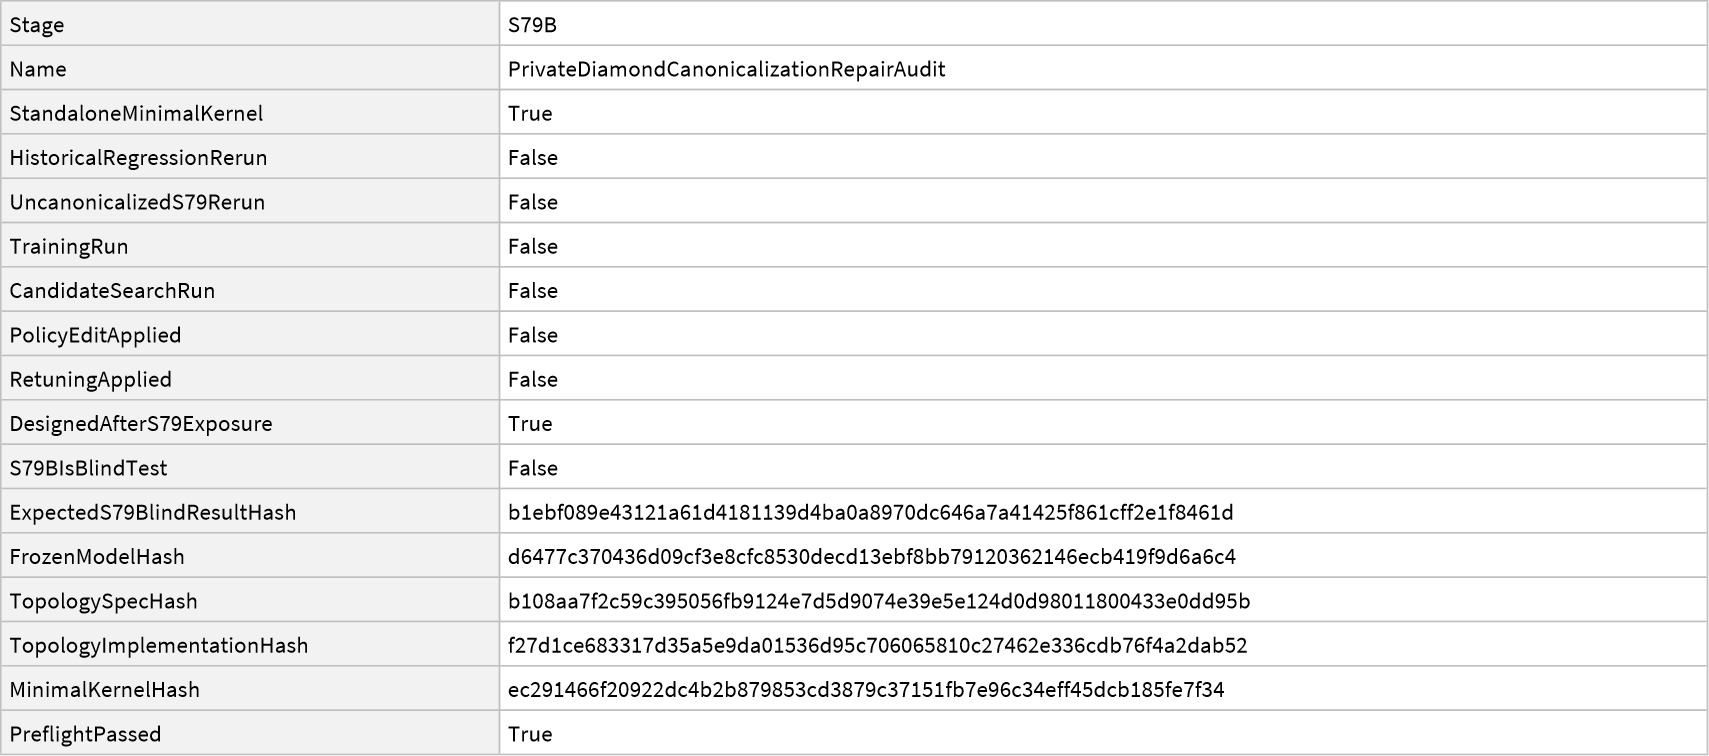

In [5]:

ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];expectedMinimalKernelHash79B=
"ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34";

minimalKernelHash79B=minimalKernelHash79A;

preflightPass79B=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[topologySpecHash79,expectedTopologySpecHash79A],
SameQ[
topologyImplementationHash79,
expectedTopologyImplementationHash79A
],
SameQ[
minimalKernelHash79B,
expectedMinimalKernelHash79B
]
];

preflight79B=<|
"Stage"->"S79B",
"Name"->"PrivateDiamondCanonicalizationRepairAudit",
"StandaloneMinimalKernel"->True,
"HistoricalRegressionRerun"->False,
"UncanonicalizedS79Rerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"DesignedAfterS79Exposure"->True,
"S79BIsBlindTest"->False,
"ExpectedS79BlindResultHash"->
expectedS79BlindResultHash79A,
"FrozenModelHash"->modelHash79A,
"TopologySpecHash"->topologySpecHash79,
"TopologyImplementationHash"->
topologyImplementationHash79,
"MinimalKernelHash"->minimalKernelHash79B,
"PreflightPassed"->preflightPass79B
|>;

If[
!TrueQ[preflightPass79B],
Print[Dataset[{preflight79B}]];
Print["S79B aborted: frozen minimal core does not match S79A."];
Abort[]
];

Dataset[{preflight79B}]


Dataset[{<|Stage -> S79B, Canonicalizer -> ProtectedPrivateDiamondQuotient, 
 
>     CanonicalizerImplementationHash -> 
 
>      5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d, 
 
>     FrozenCoreChanged -> False, PolicyEditApplied -> False, RetuningApplied -> False|>}
 
>    , TypeSystem`Vector[TypeSystem`Struct[{Stage, Canonicalizer, 
 
>      CanonicalizerImplementationHash, FrozenCoreChanged, PolicyEditApplied, 
 
>      RetuningApplied}, {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
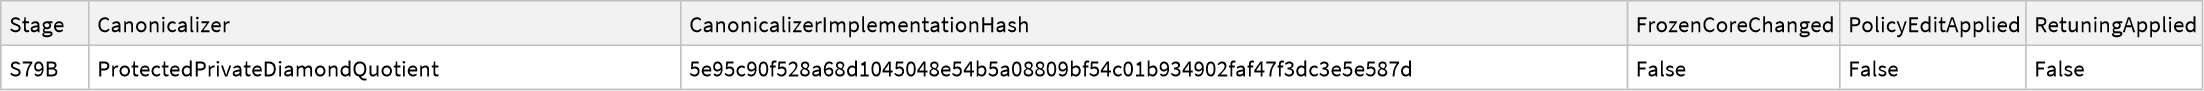

In [37]:
ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];

Dataset[{<|
"Stage"->"S79B",
"Canonicalizer"->"ProtectedPrivateDiamondQuotient",
"CanonicalizerImplementationHash"->
canonicalizerImplementationHash79B,
"FrozenCoreChanged"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False
|>}]


In [46]:
ClearAll[
PredictCodes79B,
PrepareCanonicalAuditRow79B,
CanonicalSummary79B
];

PredictCodes79B[codes_List]:=If[
AnyTrue[codes,MemberQ[frozen75D["Policy"],#]&],
"Continue",
"Stop"
];

PrepareCanonicalAuditRow79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Module[
{
originalCase,baseCase,canonicalization,canonicalCase,
expectedContractions,traceSeconds,trace,pairs,encoded,
codes,prediction
},
originalCase=CaseByTopology79B[
topology,depth,answer,target
];
baseCase=Case59[depth,answer,target];
canonicalization=CanonicalizePrivateDiamonds79B[
originalCase
];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions79B[
topology,
baseCase
];
{traceSeconds,trace}=AbsoluteTiming[
RejectTrace78[canonicalCase]
];
pairs=DecisionStatePairsFromRejects78[
canonicalCase,
trace["Rejects"]
];
encoded=First@EncodeRows75[
{<|
"Grammar"->topology,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"StatePairs"->pairs
|>},
frozen75D["Params"],
frozen75D["K"]
];
codes=encoded["Codes"];
prediction=PredictCodes79B[codes];
<|
"Topology"->topology,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],
expectedContractions
],
"ProtectedNodesPreserved"->
canonicalization["ProtectedNodesPreserved"],
"CanonicalCaseExactlyBase"->SameQ[
canonicalCase,
baseCase
],
"OriginalEdgeCount"->Length[originalCase[[1,1]]],
"CanonicalEdgeCount"->Length[canonicalCase[[1,1]]],
"TraceSeconds"->traceSeconds,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"StatePairCount"->Length[pairs],
"Codes"->codes,
"Prediction"->prediction,
"Correct"->SameQ[prediction,target]
|>
];

smallAuditRows79B=Flatten[
Table[
PrepareCanonicalAuditRow79B[
topology,
depth,
answer,
target
],
{topology,{"Base","DiamondIn","DoubleDiamondIn"}},
{depth,{5,31}},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
3
];

s79RepairRows79B=Flatten[
Table[
PrepareCanonicalAuditRow79B[
"DoubleDiamondIn",
depth,
answer,
target
],
{depth,{191,255}},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
2
];

CanonicalSummary79B[
rows_List,
topology_String,
depth_Integer
]:=Module[
{selected,continueRows,stopRows,passed},
selected=Select[
rows,
And[
SameQ[#["Topology"],topology],
SameQ[#["Depth"],depth]
]&
];
continueRows=Select[
selected,
SameQ[#["Target"],"Continue"]&
];
stopRows=Select[
selected,
SameQ[#["Target"],"Stop"]&
];
passed=Count[selected,row_/;TrueQ[row["Correct"]]];
<|
"Topology"->topology,
"Depth"->depth,
"Cases"->Length[selected],
"CanonicalCaseExactlyBase"->Count[
selected,
row_/;TrueQ[row["CanonicalCaseExactlyBase"]]
],
"ContractionCountCorrect"->Count[
selected,
row_/;TrueQ[row["ContractionCountCorrect"]]
],
"ProtectedNodesPreserved"->Count[
selected,
row_/;TrueQ[row["ProtectedNodesPreserved"]]
],
"ContractionCounts"->Counts@Lookup[
selected,
"Contractions"
],
"ContinueCodes"->Union@@Lookup[
continueRows,
"Codes"
],
"StopCodes"->Union@@Lookup[
stopRows,
"Codes"
],
"Passed"->passed,
"Accuracy"->N[passed/Length[selected]],
"TerminatedNaturally"->Count[
selected,
row_/;TrueQ[row["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[
selected,
row_/;TrueQ[row["HitSafetyCap"]]
],
"TotalTraceSeconds"->Total@Lookup[
selected,
"TraceSeconds"
]
|>
];

smallSummary79B=Flatten[
Table[
CanonicalSummary79B[
smallAuditRows79B,
topology,
depth
],
{topology,{"Base","DiamondIn","DoubleDiamondIn"}},
{depth,{5,31}}
],
1
];

s79RepairSummary79B=Map[
CanonicalSummary79B[
s79RepairRows79B,
"DoubleDiamondIn",
#
]&,
{191,255}
];

Dataset[Join[smallSummary79B,s79RepairSummary79B]]


Dataset[{<|Topology -> Base, Depth -> 5, Cases -> 8, CanonicalCaseExactlyBase -> 8, 
 
>     ContractionCountCorrect -> 8, ProtectedNodesPreserved -> 8, 
 
>     ContractionCounts -> <|0 -> 8|>, ContinueCodes -> {{3, 3}, {4, 3}}, 
 
>     StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, Accuracy -> 1., 
 
>     TerminatedNaturally -> 8, HitSafetyCap -> 0, TotalTraceSeconds -> 0.138984|>, 
 
>    <|Topology -> Base, Depth -> 31, Cases -> 8, CanonicalCaseExactlyBase -> 8, 
 
>     ContractionCountCorrect -> 8, ProtectedNodesPreserved -> 8, 
 
>     ContractionCounts -> <|0 -> 8|>, ContinueCodes -> {{3, 3}, {4, 3}}, 
 
>     StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, Accuracy -> 1., 
 
>     TerminatedNaturally -> 8, HitSafetyCap -> 0, TotalTraceSeconds -> 1.25528|>, 
 
>    <|Topology -> DiamondIn, Depth -> 5, Cases -> 8, CanonicalCaseExactlyBase -> 8, 
 
>     ContractionCountCorrect -> 8, ProtectedNodesPreserved -> 8, 
 
>     ContractionCounts -> <|12 -> 8|>, ContinueCodes -> {{3, 3}, {4, 3}}, 
 
>     StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, Accuracy -> 1., 
 
>     TerminatedNaturally -> 8, HitSafetyCap -> 0, TotalTraceSeconds -> 0.138105|>, 
 
>    <|Topology -> DiamondIn, Depth -> 31, Cases -> 8, CanonicalCaseExactlyBase -> 8, 
 
>     ContractionCountCorrect -> 8, ProtectedNodesPreserved -> 8, 
 
>     ContractionCounts -> <|12 -> 8|>, ContinueCodes -> {{3, 3}, {4, 3}}, 
 
>     StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, Accuracy -> 1., 
 
>     TerminatedNaturally -> 8, HitSafetyCap -> 0, TotalTraceSeconds -> 1.20008|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 5, Cases -> 8, 
 
>     CanonicalCaseExactlyBase -> 8, ContractionCountCorrect -> 8, 
 
>     ProtectedNodesPreserved -> 8, ContractionCounts -> <|24 -> 8|>, 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, 
 
>     Accuracy -> 1., TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 0.132877|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 31, Cases -> 8, 
 
>     CanonicalCaseExactlyBase -> 8, ContractionCountCorrect -> 8, 
 
>     ProtectedNodesPreserved -> 8, ContractionCounts -> <|24 -> 8|>, 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, 
 
>     Accuracy -> 1., TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 1.19923|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 191, Cases -> 8, 
 
>     CanonicalCaseExactlyBase -> 8, ContractionCountCorrect -> 8, 
 
>     ProtectedNodesPreserved -> 8, ContractionCounts -> <|24 -> 8|>, 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, 
 
>     Accuracy -> 1., TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 32.4233|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 255, Cases -> 8, 
 
>     CanonicalCaseExactlyBase -> 8, ContractionCountCorrect -> 8, 
 
>     ProtectedNodesPreserved -> 8, ContractionCounts -> <|24 -> 8|>, 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, Passed -> 8, 
 
>     Accuracy -> 1., TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 56.7527|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Depth, Cases, 
 
>      CanonicalCaseExactlyBase, ContractionCountCorrect, ProtectedNodesPreserved, 
 
>      ContractionCounts, ContinueCodes, StopCodes, Passed, Accuracy, 
 
>      TerminatedNaturally, HitSafetyCap, TotalTraceSeconds}, 
 
>     {TypeSystem`Atom[TypeSystem`Enumeration[Base, DiamondIn, DoubleDiamondIn]], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 2], 
 
>      TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 2], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Ato

Dataset[{<|Stage -> S79B, Name -> PrivateDiamondCanonicalizationRepairAudit, 
 
>     PriorS79FailureRerun -> False, HistoricalRegressionRerun -> False, 
 
>     SmallAuditCases -> 48, SmallAuditPassed -> 48, S79RepairCases -> 16, 
 
>     S79RepairPassed -> 16, AllCanonicalCasesExactlyBase -> True, 
 
>     AllContractionCountsCorrect -> True, FrozenModelChanged -> False, 
 
>     FrozenCoreChanged -> False, PolicyEditApplied -> False, RetuningApplied -> False, 
 
>     InputCanonicalizerAdded -> True, OverallArchitectureChanged -> True, 
 
>     DesignedAfterS79Exposure -> True, S79BIsBlindTest -> False, 
 
>     MayClaimRepairMechanism -> True, MayClaimNewBlindGeneralization -> False, 
 
>     AuditValidityPassed -> True, RepairMechanismPassed -> True, 
 
>     MechanismConclusion -> 
 
>      PRIVATE_DIAMOND_QUOTIENT_RESTORES_CANONICAL_ACTION_SEMANTICS, 
 
>     CanonicalizerImplementationHash -> 
 
>      5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d, 
 
>     ResultHash -> 0f283d3aa52ec04478ada36f580a6832f09f2d41744bec6ffe3b60dd9e5169ff, 
 
>     ScientificStatus -> POST_HOC_REPAIR_PASS_NOT_BLIND_EVIDENCE, 
 
>     SuggestedNextStage -> FREEZE_CANONICALIZER_THEN_S80_NEW_BLIND_NEUTRAL_REWRITE|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 27], 
 
>    1], <||>]
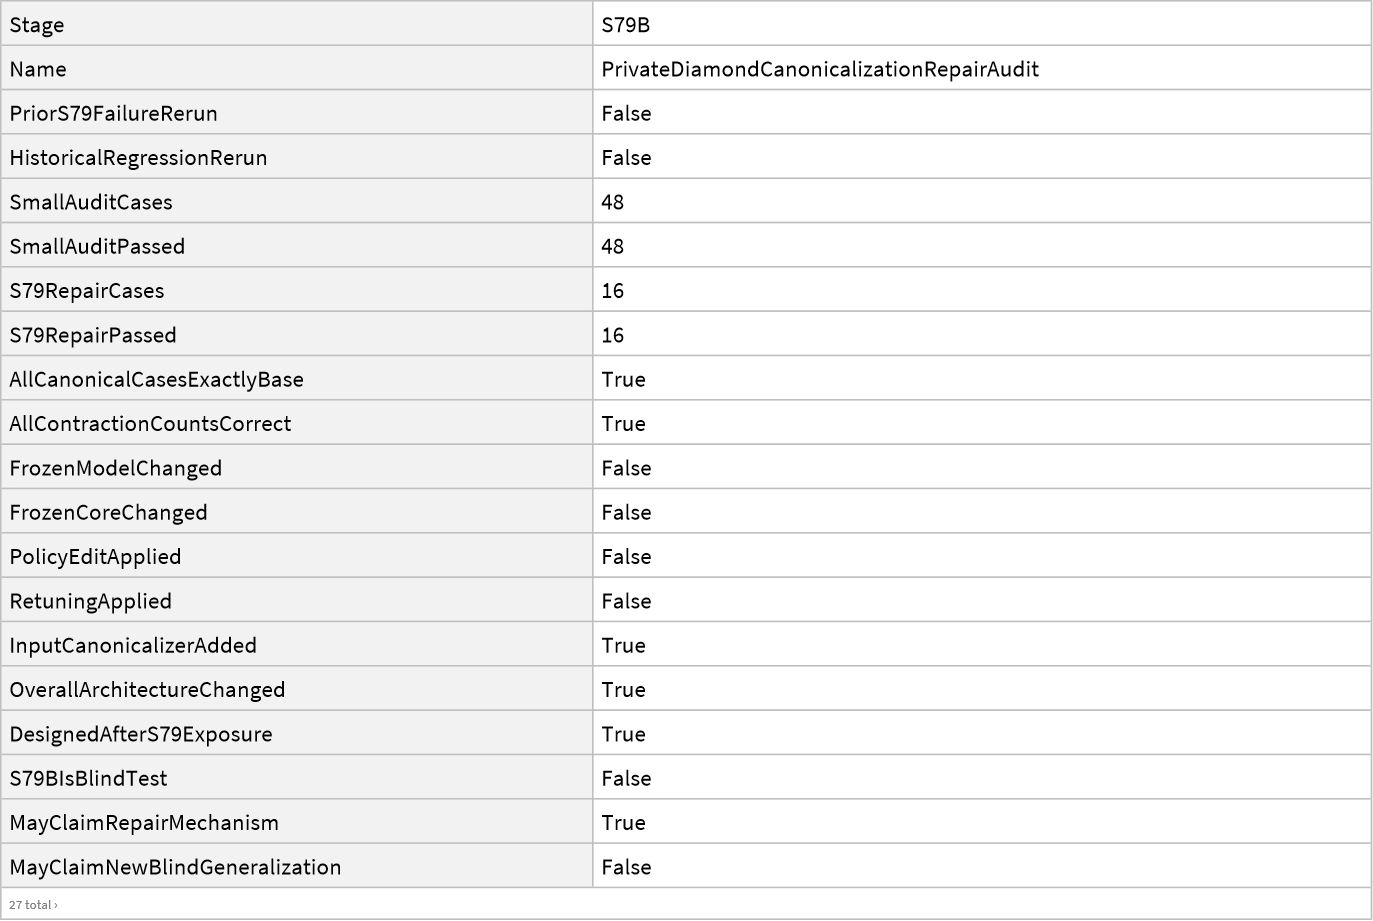

In [55]:
smallAuditPassed79B=And[
SameQ[Length[smallAuditRows79B],48],
SameQ[
Count[
smallAuditRows79B,
row_/;TrueQ[row["CanonicalCaseExactlyBase"]]
],
48
],
SameQ[
Count[
smallAuditRows79B,
row_/;TrueQ[row["ContractionCountCorrect"]]
],
48
],
SameQ[
Count[
smallAuditRows79B,
row_/;TrueQ[row["Correct"]]
],
48
],
SameQ[
Count[
smallAuditRows79B,
row_/;TrueQ[row["TerminatedNaturally"]]
],
48
],
SameQ[
Count[
smallAuditRows79B,
row_/;TrueQ[row["HitSafetyCap"]]
],
0
]
];

s79RepairPassed79B=And[
SameQ[Length[s79RepairRows79B],16],
SameQ[
Count[
s79RepairRows79B,
row_/;TrueQ[row["CanonicalCaseExactlyBase"]]
],
16
],
SameQ[
Count[
s79RepairRows79B,
row_/;TrueQ[row["ContractionCountCorrect"]]
],
16
],
SameQ[
Count[
s79RepairRows79B,
row_/;TrueQ[row["Correct"]]
],
16
],
SameQ[
Count[
s79RepairRows79B,
row_/;TrueQ[row["TerminatedNaturally"]]
],
16
],
SameQ[
Count[
s79RepairRows79B,
row_/;TrueQ[row["HitSafetyCap"]]
],
0
]
];

modelHashAfter79B=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

modelUnchanged79B=SameQ[
modelHashAfter79B,
expectedFrozenModelHash79A
];

auditValidityPassed79B=And[
TrueQ[preflightPass79B],
TrueQ[smallAuditPassed79B],
TrueQ[modelUnchanged79B]
];

repairMechanismPassed79B=And[
TrueQ[auditValidityPassed79B],
TrueQ[s79RepairPassed79B]
];

resultPayload79B=<|
"Stage"->"S79B",
"Name"->"PrivateDiamondCanonicalizationRepairAudit",
"PriorS79BlindResultHash"->
expectedS79BlindResultHash79A,
"PriorS79FailureRerun"->False,
"HistoricalRegressionRerun"->False,
"SmallAuditCases"->Length[smallAuditRows79B],
"SmallAuditPassed"->Count[
smallAuditRows79B,
row_/;TrueQ[row["Correct"]]
],
"S79RepairCases"->Length[s79RepairRows79B],
"S79RepairPassed"->Count[
s79RepairRows79B,
row_/;TrueQ[row["Correct"]]
],
"AllCanonicalCasesExactlyBase"->And[
And@@Lookup[
smallAuditRows79B,
"CanonicalCaseExactlyBase"
],
And@@Lookup[
s79RepairRows79B,
"CanonicalCaseExactlyBase"
]
],
"AllContractionCountsCorrect"->And[
And@@Lookup[
smallAuditRows79B,
"ContractionCountCorrect"
],
And@@Lookup[
s79RepairRows79B,
"ContractionCountCorrect"
]
],
"CanonicalizerImplementationHash"->
canonicalizerImplementationHash79B,
"FrozenModelHash"->modelHashAfter79B,
"FrozenModelChanged"->!TrueQ[modelUnchanged79B],
"FrozenCoreChanged"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"CandidateSearchRun"->False,
"InputCanonicalizerAdded"->True,
"OverallArchitectureChanged"->True,
"DesignedAfterS79Exposure"->True,
"S79LabelsUsedByCanonicalizer"->False,
"S79LabelsUsedForPolicyOrParameterSelection"->False,
"S79BIsBlindTest"->False,
"MayClaimRepairMechanism"->
repairMechanismPassed79B,
"MayClaimNewBlindGeneralization"->False,
"AuditValidityPassed"->auditValidityPassed79B,
"RepairMechanismPassed"->repairMechanismPassed79B,
"MechanismConclusion"->If[
TrueQ[repairMechanismPassed79B],
"PRIVATE_DIAMOND_QUOTIENT_RESTORES_CANONICAL_ACTION_SEMANTICS",
"CANONICALIZATION_REPAIR_NOT_ESTABLISHED"
]
|>;

resultHash79B=Hash[
Normal[resultPayload79B],
"SHA256",
"HexString"
];

cert79B=Join[
resultPayload79B,
<|
"AuditOnly"->True,
"ResultHash"->resultHash79B,
"ScientificStatus"->If[
TrueQ[repairMechanismPassed79B],
"POST_HOC_REPAIR_PASS_NOT_BLIND_EVIDENCE",
"REPAIR_AUDIT_FAILED"
],
"SuggestedNextStage"->If[
TrueQ[repairMechanismPassed79B],
"FREEZE_CANONICALIZER_THEN_S80_NEW_BLIND_NEUTRAL_REWRITE",
"DIAGNOSE_S79B_WITHOUT_EDITING_FROZEN_POLICY"
]
|>
];

Dataset[{KeyTake[
cert79B,
{
"Stage",
"Name",
"PriorS79FailureRerun",
"HistoricalRegressionRerun",
"SmallAuditCases",
"SmallAuditPassed",
"S79RepairCases",
"S79RepairPassed",
"AllCanonicalCasesExactlyBase",
"AllContractionCountsCorrect",
"FrozenModelChanged",
"FrozenCoreChanged",
"PolicyEditApplied",
"RetuningApplied",
"InputCanonicalizerAdded",
"OverallArchitectureChanged",
"DesignedAfterS79Exposure",
"S79BIsBlindTest",
"MayClaimRepairMechanism",
"MayClaimNewBlindGeneralization",
"AuditValidityPassed",
"RepairMechanismPassed",
"MechanismConclusion",
"CanonicalizerImplementationHash",
"ResultHash",
"ScientificStatus",
"SuggestedNextStage"
}
]}]
